In [1]:
from __future__ import annotations

%matplotlib widget

import logging

import matplotlib.pyplot as plt
import numpy as np

logging.basicConfig(level=logging.INFO)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("rydstate").setLevel(logging.WARNING)

In [2]:
from typing import TYPE_CHECKING

import rydstate

if TYPE_CHECKING:
    from rydstate.rydberg_state import RydbergState

In [3]:
species = "Yb174"
l_r = 1
f_tot = 1
nu_range = (0, 150)

basis_sqdt_full = rydstate.BasisOQDT(species, nu=nu_range, l_r=(l_r, l_r), f_tot=(f_tot, f_tot))

In [4]:
basis_sqdt_full.sort_states("nu")
print(f"basis_sqdt_full: {len(basis_sqdt_full.states)} states")

basis_sqdt_full: 301 states


In [5]:
basis_sqdt = basis_sqdt_full.shallow_copy()

basis_dict: dict[str, rydstate.basis.BasisBase[RydbergState]] = {}

basis_dict["6sns jr=1/2"] = (
    basis_sqdt.shallow_copy().filter_states("l_c", 0).filter_states("l_r", l_r).filter_states("j_r", 1 / 2)
)

basis_dict["6sns jr=3/2"] = (
    basis_sqdt.shallow_copy().filter_states("l_c", 0).filter_states("l_r", l_r).filter_states("j_r", 3 / 2)
)

# the perturber channels have parity (-1)**l_r, i.e. -1 for the l_r = 1 states considered here
parity = (-1) ** l_r
for key in ["4f13 5d 6snl a", "4f13 5d 6snl b", "4f13 5d 6snl c", "4f13 5d 6snl d"]:
    basis_dict[key] = basis_sqdt.shallow_copy().filter_states("parity", parity).filter_states_label(key)


basis_mqdt = rydstate.BasisMQDT(species, nu=nu_range, f_tot=(f_tot, f_tot), l_r=(l_r, l_r))
basis_dict["full MQDT"] = basis_mqdt

for key, basis in basis_dict.items():
    print(f"{key}: {len(basis.states)} states")
    for state in basis.states[:3]:
        print(f"  {state}")
    print("  ...\n")

6sns jr=1/2: 148 states
  |Yb174:(6s_1/2,[2.0]p_1/2),J=1⟩
  |Yb174:(6s_1/2,[3.2]p_1/2),J=1⟩
  |Yb174:(6s_1/2,[4.1]p_1/2),J=1⟩
  ...

6sns jr=3/2: 148 states
  |Yb174:(6s_1/2,[1.9]p_3/2),J=1⟩
  |Yb174:(6s_1/2,[3.3]p_3/2),J=1⟩
  |Yb174:(6s_1/2,[4.2]p_3/2),J=1⟩
  ...

4f13 5d 6snl a: 1 states
  |Yb174:nu=1.8,4f13 5d 6snl a⟩
  ...

4f13 5d 6snl b: 1 states
  |Yb174:nu=1.8,4f13 5d 6snl b⟩
  ...

4f13 5d 6snl c: 1 states
  |Yb174:nu=1.8,4f13 5d 6snl c⟩
  ...

4f13 5d 6snl d: 0 states
  ...

full MQDT: 298 states
  0.69*|Yb174:(6s_1/2,[1.8]p_3/2),J=1⟩ + 0.73*|Yb174:(6s_1/2,[1.8]p_1/2),J=1⟩
  -0.4*|Yb174:(6s_1/2,[2.1]p_3/2),J=1⟩ + 0.92*|Yb174:(6s_1/2,[2.1]p_1/2),J=1⟩
  0.58*|Yb174:(6s_1/2,[3.0]p_3/2),J=1⟩ + 0.82*|Yb174:(6s_1/2,[3.0]p_1/2),J=1⟩
  ...



In [6]:
overlaps_dict: dict[str, list[float]] = {}

for key, basis in basis_dict.items():
    if isinstance(basis, rydstate.basis.BasisMQDT):
        continue

    overlaps = basis_mqdt.calc_reduced_overlaps(basis)
    overlaps_dict[key] = np.sum(overlaps**2, axis=1).tolist()

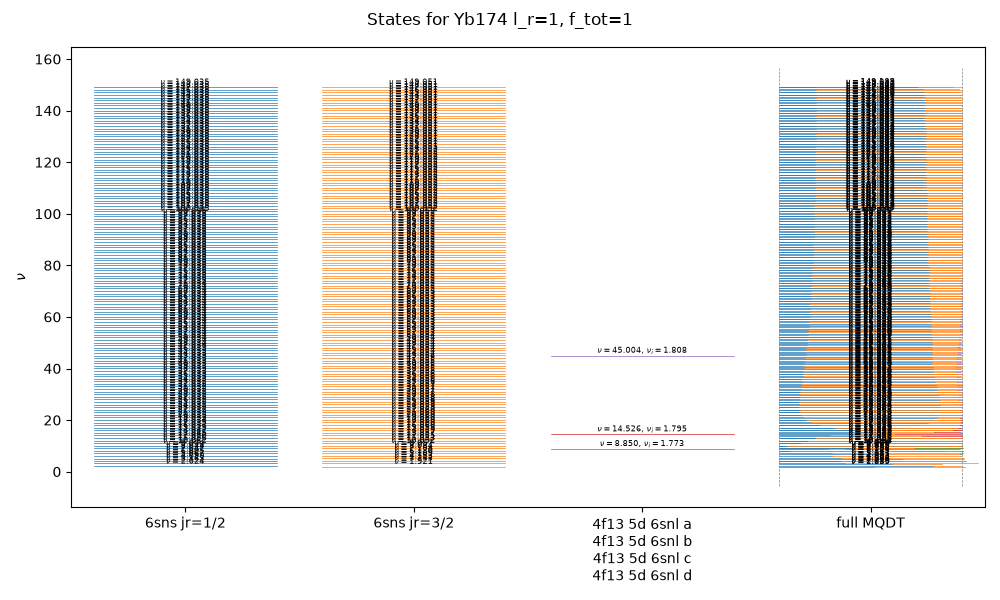

In [7]:
x_loc = {
    # S_05
    "6sns jr=1/2": 0,
    "6sns jr=3/2": 1,
    # general
    "4f13 5d 6snl a": 2,
    "4f13 5d 6snl b": 2,
    "4f13 5d 6snl c": 2,
    "4f13 5d 6snl d": 2,
    # mqdt
    "full MQDT": 3,
}


fig, ax = plt.subplots(figsize=(10, 6))

keys = list(basis_dict.keys())
keys_mo_mqdt = [key for key in keys if "MQDT" not in key]

# OQDT states
for i, key in enumerate(keys_mo_mqdt):
    x = x_loc.get(key)
    for state in basis_dict[key].states:
        if np.isinf(state.nu):
            continue

        ax.plot([x - 0.4, x + 0.4], [state.nu, state.nu], color=f"C{i}", lw=0.5, zorder=0)

        # label = rf"$n={state.n}$, $\nu={state.nu:.3f}$"
        label = rf"$\nu={state.nu:.3f}$"
        assert len(state.nui) == 1, f"Expected len(state.nui) == 1, got {len(state.nui)}"
        nui = state.nui[0]
        if not np.isclose(state.nu, nui):
            label += rf", $\nu_{{i}}={nui:.3f}$"
        ax.text(x, state.nu, label, ha="center", va="bottom", fontsize=6, clip_on=True)

# MQDT states
for ids, state in enumerate(basis_mqdt.states):
    if np.isinf(state.nu):
        continue
    overlaps = {key: overlaps_dict[key][ids] for key in keys_mo_mqdt}
    x0 = x_loc["full MQDT"] - 0.4
    for i, key in enumerate(keys_mo_mqdt):
        overlap = overlaps[key]
        x1 = x0 + overlap * 0.8
        ax.plot([x0, x1], [state.nu, state.nu], color=f"C{i}", lw=0.5, zorder=0)
        x0 = x1
    ax.text(x_loc["full MQDT"], state.nu, rf"$\nu={state.nu:.3f}$", ha="center", va="bottom", fontsize=6, clip_on=True)

ylim = ax.get_ylim()
ax.plot([x_loc["full MQDT"] - 0.4, x_loc["full MQDT"] - 0.4], ylim, color="0.5", lw=0.5, ls="--", zorder=0)
ax.plot([x_loc["full MQDT"] + 0.4, x_loc["full MQDT"] + 0.4], ylim, color="0.5", lw=0.5, ls="--", zorder=0)


fig.suptitle(f"States for {species} {l_r=}, {f_tot=}")
xticklabels = {}
for key, x in x_loc.items():
    if x not in xticklabels:
        xticklabels[x] = key
    else:
        xticklabels[x] += f"\n{key}"
ax.set_xticks(list(xticklabels.keys()))
ax.set_xticklabels(list(xticklabels.values()))
ax.set_ylabel(r"$\nu$")

ax.set_xlim(-0.5, len(xticklabels) - 0.5)

plt.tight_layout()
plt.show()